# Finance Tracker — Exploration & Experiment Notebook
### Exponential Smoothing on Multi-User Financial Dataset (2019–2023)

**Dataset:** `data_1.csv` — 3000 rows, 944 users, 60 time periods  
**Targets:** `monthly_expense_total`, `actual_savings`, `monthly_income`

**Notebook flow:**
1. Load & explore raw data
2. Aggregate to monthly time series
3. Train/Test split
4. Exponential smoothing — core logic
5. Grid search for best α per target
6. Evaluate: MAE, RMSE, MAPE
7. Visualise predictions vs actuals + residuals
8. Forecast future periods
9. Bonus: Per-user smoothing example


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

TARGETS     = ['monthly_expense_total', 'actual_savings', 'monthly_income']
TRAIN_RATIO = 0.8
ALPHA_RANGE = np.round(np.arange(0.1, 1.0, 0.1), 1)
FORECAST_N  = 3


## 1. Load & Explore Raw Data

In [23]:
df = pd.read_csv('data_1.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"Unique periods: {df['date'].nunique()}")
df.head()


Shape: (3000, 25)
Date range: 2019-01-01 → 2023-11-06
Unique users: 944
Unique periods: 60


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Low,0.00,0
1,2019-01-01,1177,3593.89,3401.82,0.25,2155.52,normal,619,0.13,725.61,...,348.61,3220.52,Salary,862.47,Insurance,Positive,68.3,High,192.07,0
2,2019-01-01,1997,2578.18,2314.40,0.07,2979.66,recession,771,0.33,487.37,...,449.34,1991.85,Salary,1062.60,Dining Out,Positive,31.5,High,263.78,0
3,2019-01-01,1254,2335.32,3350.56,0.06,2856.34,inflation,659,0.23,813.66,...,624.75,2607.93,Salary,1172.80,Transportation,Neutral,5.2,Medium,0.00,0
4,2019-01-01,1180,2739.60,3771.22,0.20,2381.32,inflation,699,0.12,202.75,...,187.94,1717.87,Salary,1093.59,Dining Out,Positive,15.4,Low,0.00,0


In [24]:
df.describe().round(2).T[['mean','std','min','max']]


,mean,std,min,max
date,2021-06-04 00:00:00,NaN,2019-01-01 00:00:00,2023-11-06 00:00:00
user_id,1498.7,287.35,1000.0,1999.0
monthly_income,4004.27,1000.11,685.28,7407.94
monthly_expense_total,3011.68,801.15,159.21,5853.2
savings_rate,0.23,0.1,0.05,0.4
budget_goal,2811.07,490.86,1175.57,4386.5
credit_score,679.92,49.97,515.0,847.0
debt_to_income_ratio,0.35,0.15,0.1,0.6
loan_payment,508.58,199.44,0.0,1176.88
investment_amount,400.61,235.36,0.0,1292.3


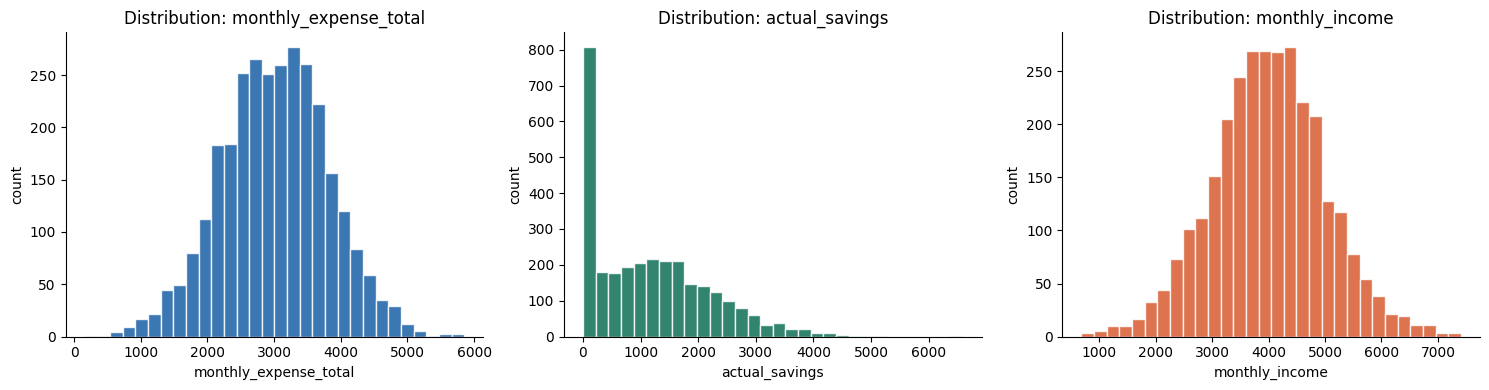

In [25]:
# Distribution of key numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, TARGETS, ['#185FA5','#0F6E56','#D85A30']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()


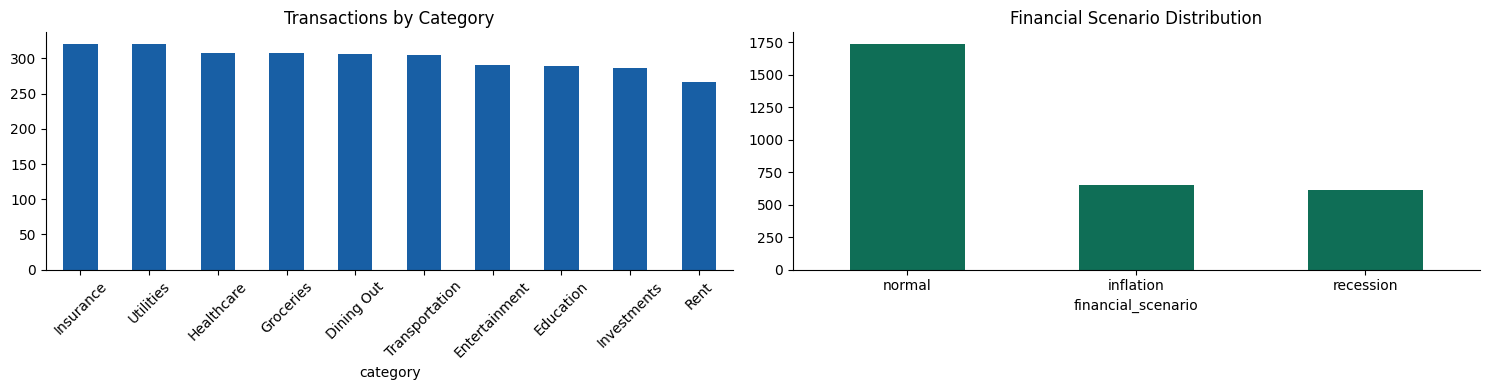

In [26]:
# Category & financial scenario breakdown
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df['category'].value_counts().plot(kind='bar', ax=axes[0], color='#185FA5', edgecolor='none')
axes[0].set_title('Transactions by Category')
axes[0].tick_params(axis='x', rotation=45)

df['financial_scenario'].value_counts().plot(kind='bar', ax=axes[1], color='#0F6E56', edgecolor='none')
axes[1].set_title('Financial Scenario Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


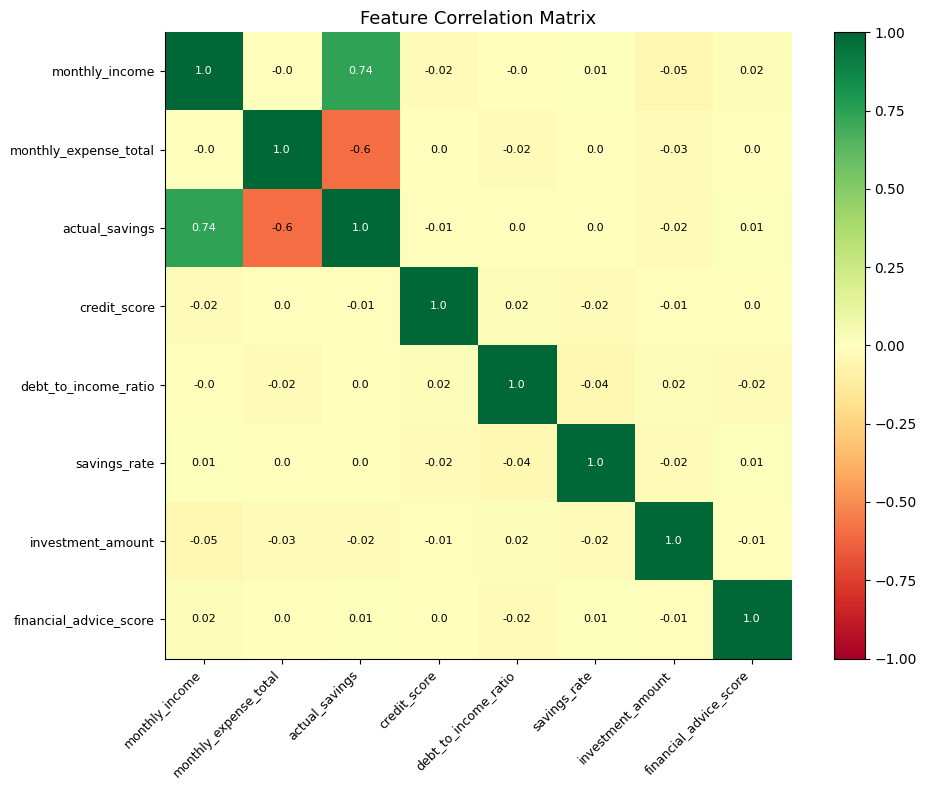

In [27]:
# Correlation heatmap for numeric columns
import matplotlib.patches as mpatches

num_cols = ['monthly_income','monthly_expense_total','actual_savings',
            'credit_score','debt_to_income_ratio','savings_rate',
            'investment_amount','financial_advice_score']
corr = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, str(corr.iloc[i, j]), ha='center', va='center', fontsize=8,
                color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()


## 2. Aggregate to Monthly Time Series

In [28]:
monthly = (
    df.groupby('date')[TARGETS]
    .mean()
    .sort_index()
    .round(2)
)
print(f"Monthly series: {len(monthly)} periods")
monthly


Monthly series: 60 periods


,monthly_expense_total,actual_savings,monthly_income
date,,,
2019-01-01,2931.66,1142.94,3900.58
2019-01-31,3036.12,1056.38,3957.87
2019-03-02,2934.44,1154.64,3967.04
2019-04-01,3169.50,1044.57,4037.38
2019-05-01,3009.93,1156.59,4051.70
2019-05-31,2823.27,1351.39,4051.22
2019-06-30,2974.84,1251.18,4063.73
2019-07-30,2996.84,1188.71,3956.56
2019-08-29,3006.03,1282.17,4116.44


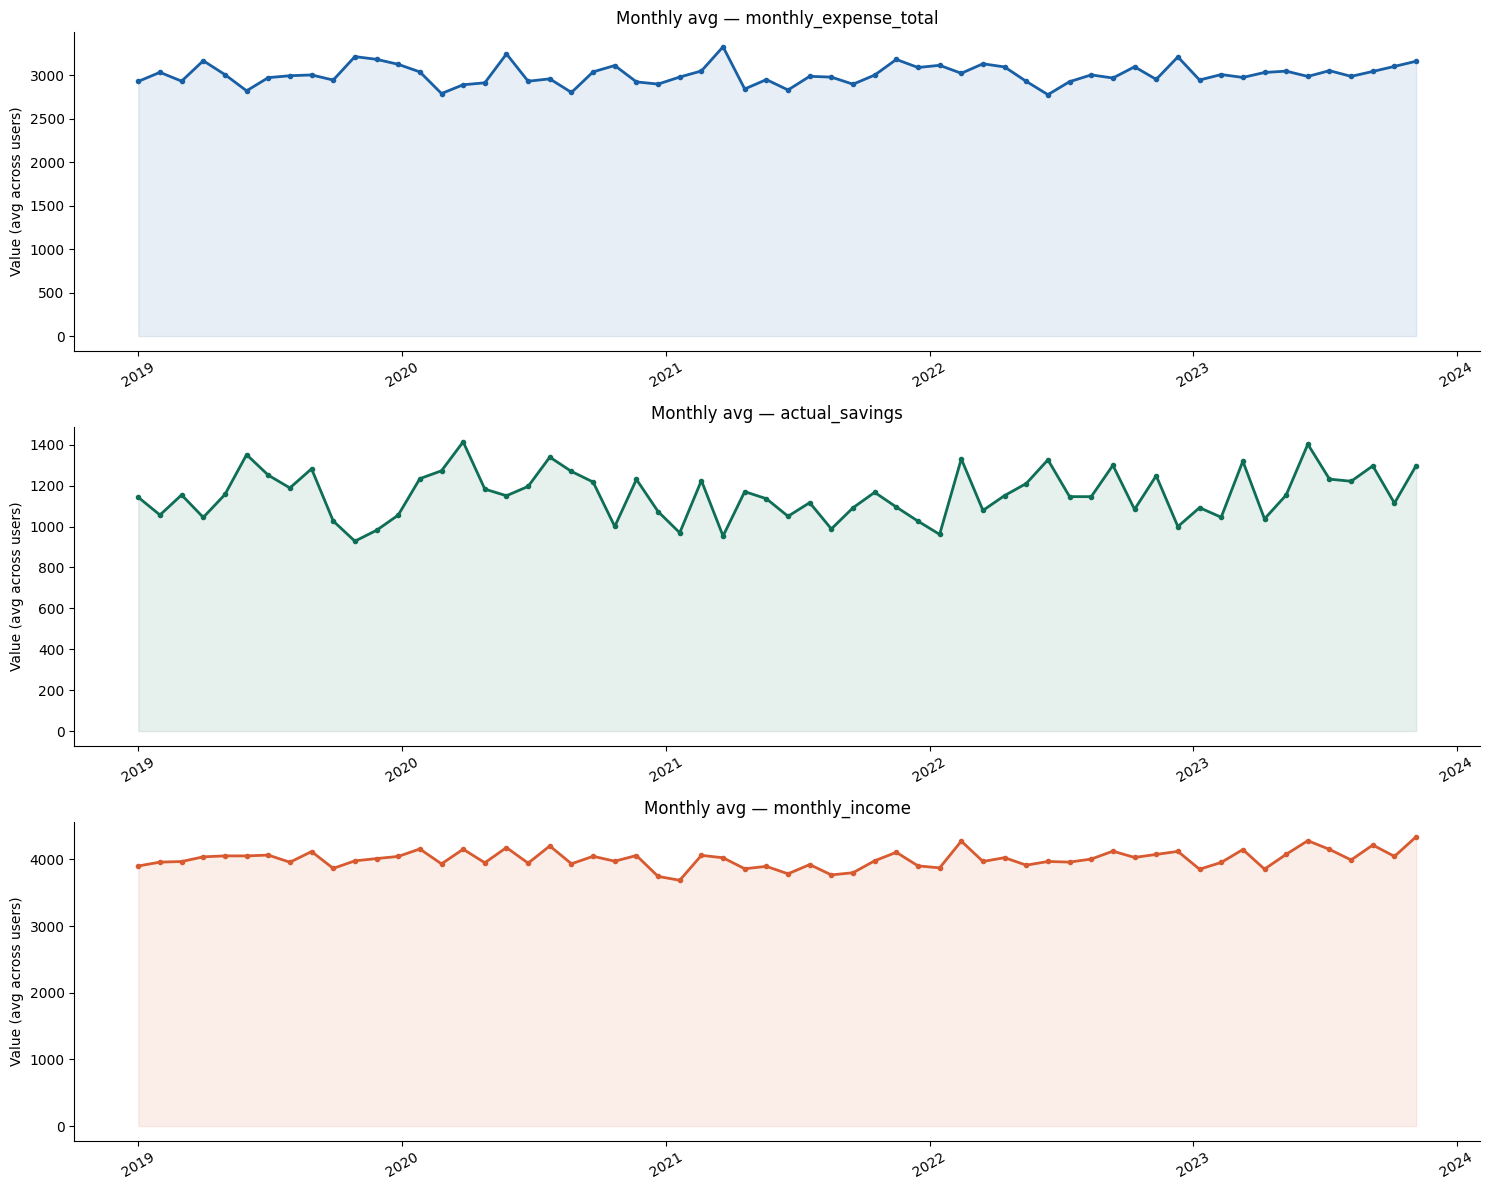

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
colors = ['#185FA5', '#0F6E56', '#D85A30']

for ax, target, color in zip(axes, TARGETS, colors):
    ax.plot(monthly.index, monthly[target], color=color, linewidth=2, marker='o', markersize=3)
    ax.fill_between(monthly.index, monthly[target], alpha=0.1, color=color)
    ax.set_title(f'Monthly avg — {target}')
    ax.set_ylabel('Value (avg across users)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 3. Train / Test Split

In [30]:
n       = len(monthly)
n_train = int(n * TRAIN_RATIO)
n_test  = n - n_train

train_idx = monthly.index[:n_train]
test_idx  = monthly.index[n_train:]

print(f"Total  : {n} periods")
print(f"Train  : {n_train}  ({train_idx[0].date()} → {train_idx[-1].date()})")
print(f"Test   : {n_test}   ({test_idx[0].date()} → {test_idx[-1].date()})")


Total  : 60 periods
Train  : 48  (2019-01-01 → 2022-11-11)
Test   : 12   (2022-12-11 → 2023-11-06)


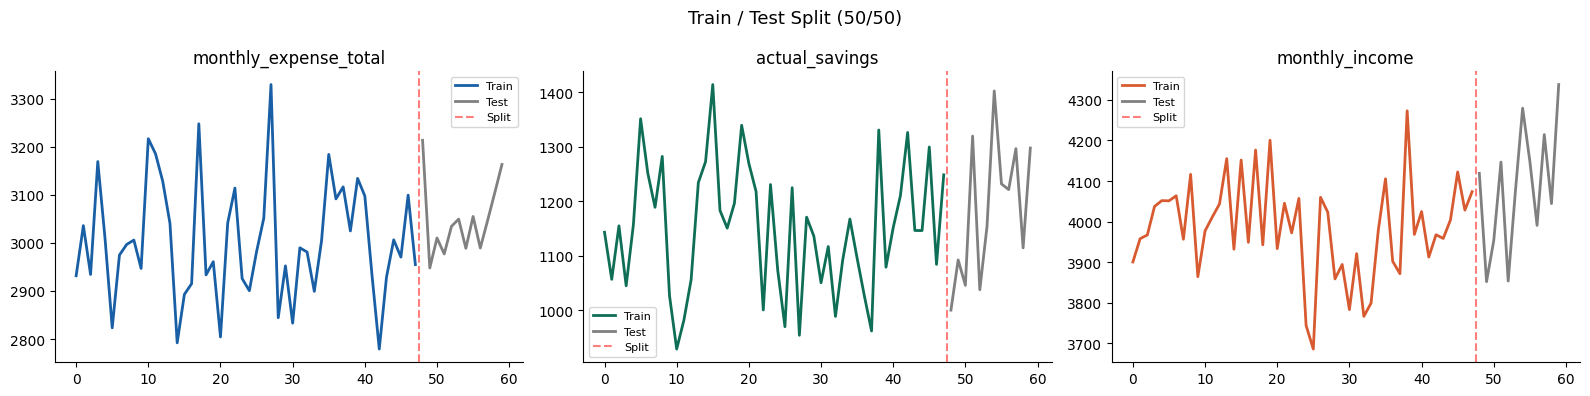

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#185FA5', '#0F6E56', '#D85A30']

for ax, target, color in zip(axes, TARGETS, colors):
    vals = monthly[target].values
    ax.plot(range(n_train), vals[:n_train], color=color, label='Train', linewidth=2)
    ax.plot(range(n_train, n), vals[n_train:], color='gray', label='Test', linewidth=2)
    ax.axvline(n_train - 0.5, color='red', linestyle='--', alpha=0.5, label='Split')
    ax.set_title(target)
    ax.legend(fontsize=8)

plt.suptitle('Train / Test Split (50/50)', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Exponential Smoothing — Core Functions

In [32]:
def exp_smooth(series, alpha):
    """
    Single Exponential Smoothing
        S(t) = α · X(t) + (1 − α) · S(t−1)

    α near 1  →  reacts fast to recent observations (reactive)
    α near 0  →  slow to update, heavy smoothing (stable)

    Choosing alpha:
      - Stable/slow-changing series → small α (0.1–0.2)
      - Volatile/noisy series       → larger α (0.5–0.8)
      - Best practice: let grid search on test set decide
    """
    s = np.zeros(len(series))
    s[0] = series[0]
    for t in range(1, len(series)):
        s[t] = alpha * series[t] + (1 - alpha) * s[t - 1]
    return s

def predict_test(train, n_test, alpha):
    """Seed from last smoothed train value; flat forecast for test window."""
    smoothed = exp_smooth(train, alpha)
    return np.full(n_test, smoothed[-1])

def mae(actual, pred):   return np.mean(np.abs(actual - pred))
def rmse(actual, pred):  return np.sqrt(np.mean((actual - pred) ** 2))
def mape(actual, pred):  return np.mean(np.abs((actual - pred) / (actual + 1e-9))) * 100

print("Functions ready.")


Functions ready.


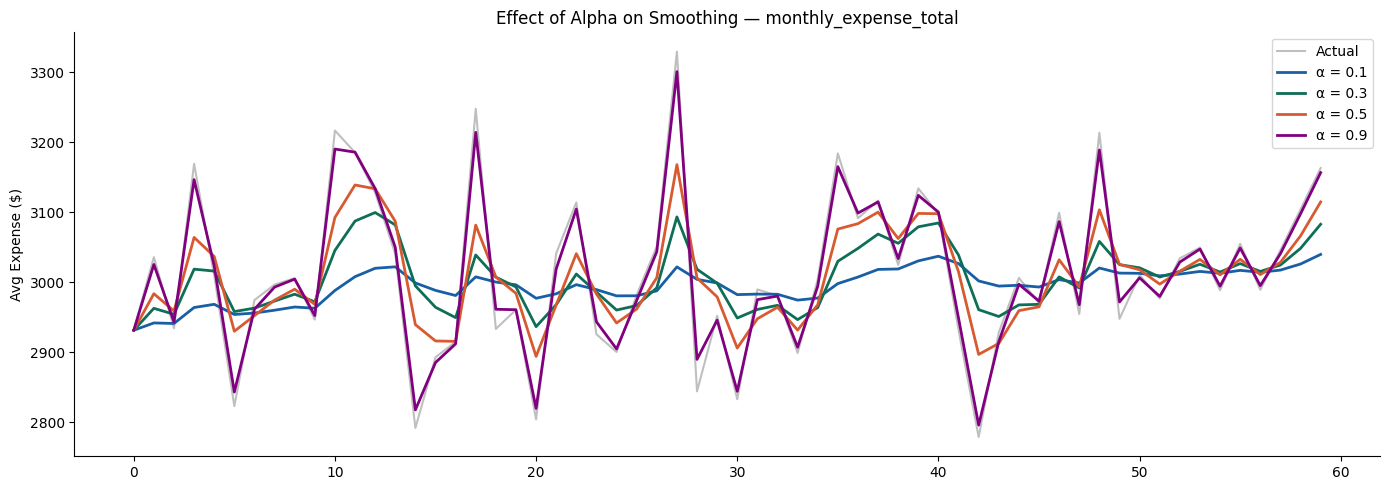

In [33]:
# Visualise effect of alpha on smoothing
sample = monthly['monthly_expense_total'].values
x_axis = range(len(sample))

fig, ax = plt.subplots()
ax.plot(x_axis, sample, color='gray', alpha=0.5, linewidth=1.5, label='Actual')
for alpha, color in zip([0.1, 0.3, 0.5, 0.9], ['#185FA5','#0F6E56','#D85A30','purple']):
    smoothed = exp_smooth(sample, alpha)
    ax.plot(x_axis, smoothed, linewidth=2, label=f'α = {alpha}', color=color)

ax.set_title('Effect of Alpha on Smoothing — monthly_expense_total')
ax.set_ylabel('Avg Expense ($)')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Grid Search — Best Alpha per Target

In [34]:
def grid_search(train, test):
    rows = []
    for alpha in ALPHA_RANGE:
        preds = predict_test(train, len(test), alpha)
        rows.append({
            'alpha': alpha,
            'MAE':   round(mae(test, preds), 2),
            'RMSE':  round(rmse(test, preds), 2),
            'MAPE':  round(mape(test, preds), 2),
        })
    return pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)

best_alphas = {}
all_results = {}

for target in TARGETS:
    vals   = monthly[target].values.astype(float)
    train  = vals[:n_train]
    test   = vals[n_train:]
    res    = grid_search(train, test)
    best_alphas[target]  = res.iloc[0]['alpha']
    all_results[target]  = res
    print(f"\n── {target}")
    print(res.to_string(index=False))
    print(f"  → Best α = {res.iloc[0]['alpha']}   MAE = {res.iloc[0]['MAE']:.2f}   MAPE = {res.iloc[0]['MAPE']:.1f}%")



── monthly_expense_total
 alpha   MAE   RMSE  MAPE
   0.1 64.82  89.81  2.08
   0.2 66.50  92.66  2.13
   0.5 66.64  92.91  2.14
   0.4 66.86  93.31  2.15
   0.3 67.17  93.87  2.16
   0.6 67.24  93.99  2.16
   0.7 69.66  97.07  2.24
   0.8 74.99 102.33  2.41
   0.9 83.61 109.88  2.69
  → Best α = 0.1   MAE = 64.82   MAPE = 2.1%

── actual_savings
 alpha    MAE   RMSE  MAPE
   0.1 110.52 125.67  9.28
   0.2 110.52 123.90  9.45
   0.3 110.52 124.44  9.54
   0.4 110.52 124.96  9.57
   0.5 110.52 125.47  9.60
   0.6 110.52 126.24  9.64
   0.7 110.52 127.55  9.69
   0.8 110.80 129.77  9.78
   0.9 113.00 133.45 10.04
  → Best α = 0.1   MAE = 110.52   MAPE = 9.3%

── monthly_income
 alpha    MAE   RMSE  MAPE
   0.9 124.01 148.94  3.04
   0.8 124.45 149.22  3.04
   0.7 124.84 149.51  3.05
   0.6 125.36 149.95  3.06
   0.5 126.14 150.73  3.08
   0.4 127.32 152.18  3.10
   0.3 129.83 154.86  3.16
   0.2 135.32 160.41  3.28
   0.1 144.61 172.99  3.49
  → Best α = 0.9   MAE = 124.01   MAPE = 3.0%

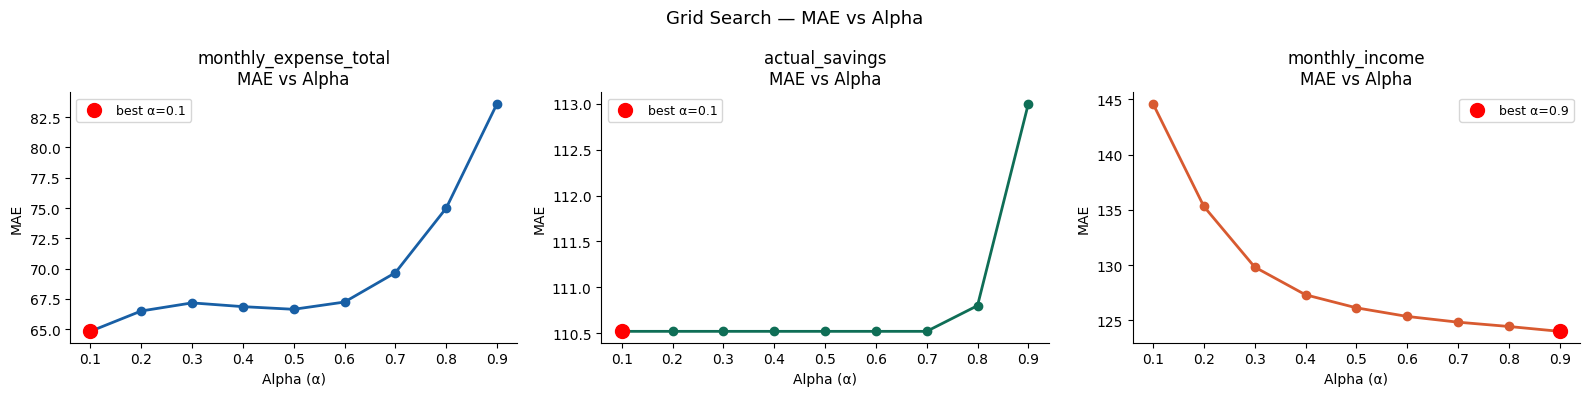

In [35]:
# Alpha vs MAE plot for all targets
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#185FA5', '#0F6E56', '#D85A30']

for ax, target, color in zip(axes, TARGETS, colors):
    res = all_results[target]
    maes  = res.sort_values('alpha')['MAE'].values
    alphs = res.sort_values('alpha')['alpha'].values
    best  = best_alphas[target]
    best_mae = res[res['alpha']==best]['MAE'].values[0]

    ax.plot(alphs, maes, marker='o', color=color, linewidth=2)
    ax.scatter([best], [best_mae], color='red', zorder=5, s=100, label=f'best α={best}')
    ax.set_title(f'{target}\nMAE vs Alpha')
    ax.set_xlabel('Alpha (α)')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=9)

plt.suptitle('Grid Search — MAE vs Alpha', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Evaluate: Predictions vs Actuals on Test Set

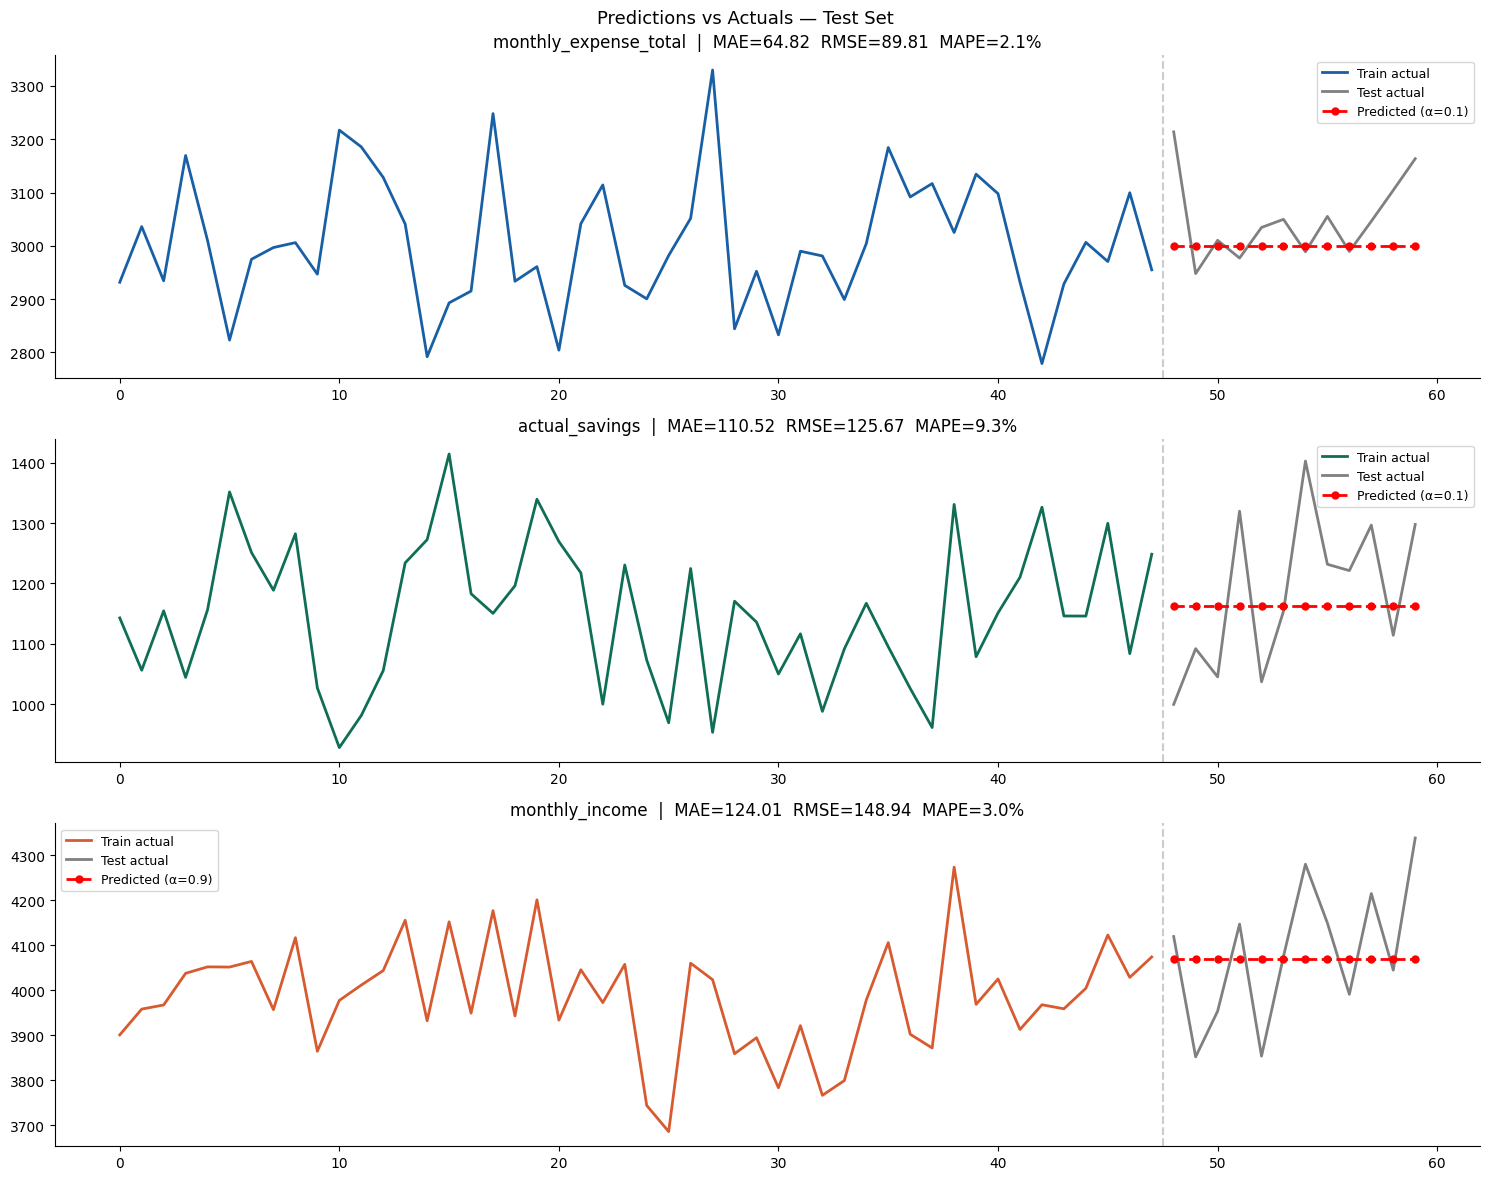

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
colors = ['#185FA5', '#0F6E56', '#D85A30']

for ax, target, color in zip(axes, TARGETS, colors):
    vals  = monthly[target].values.astype(float)
    train = vals[:n_train]
    test  = vals[n_train:]
    alpha = best_alphas[target]
    preds = predict_test(train, n_test, alpha)

    ax.plot(range(n_train), train, color=color, linewidth=2, label='Train actual')
    ax.plot(range(n_train, n), test, color='gray', linewidth=2, label='Test actual')
    ax.plot(range(n_train, n), preds, 'o--', color='red', linewidth=2,
            markersize=5, label=f'Predicted (α={alpha})')
    ax.axvline(n_train - 0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_title(f'{target}  |  MAE={mae(test,preds):.2f}  RMSE={rmse(test,preds):.2f}  MAPE={mape(test,preds):.1f}%')
    ax.legend(fontsize=9)

plt.suptitle('Predictions vs Actuals — Test Set', fontsize=13)
plt.tight_layout()
plt.show()


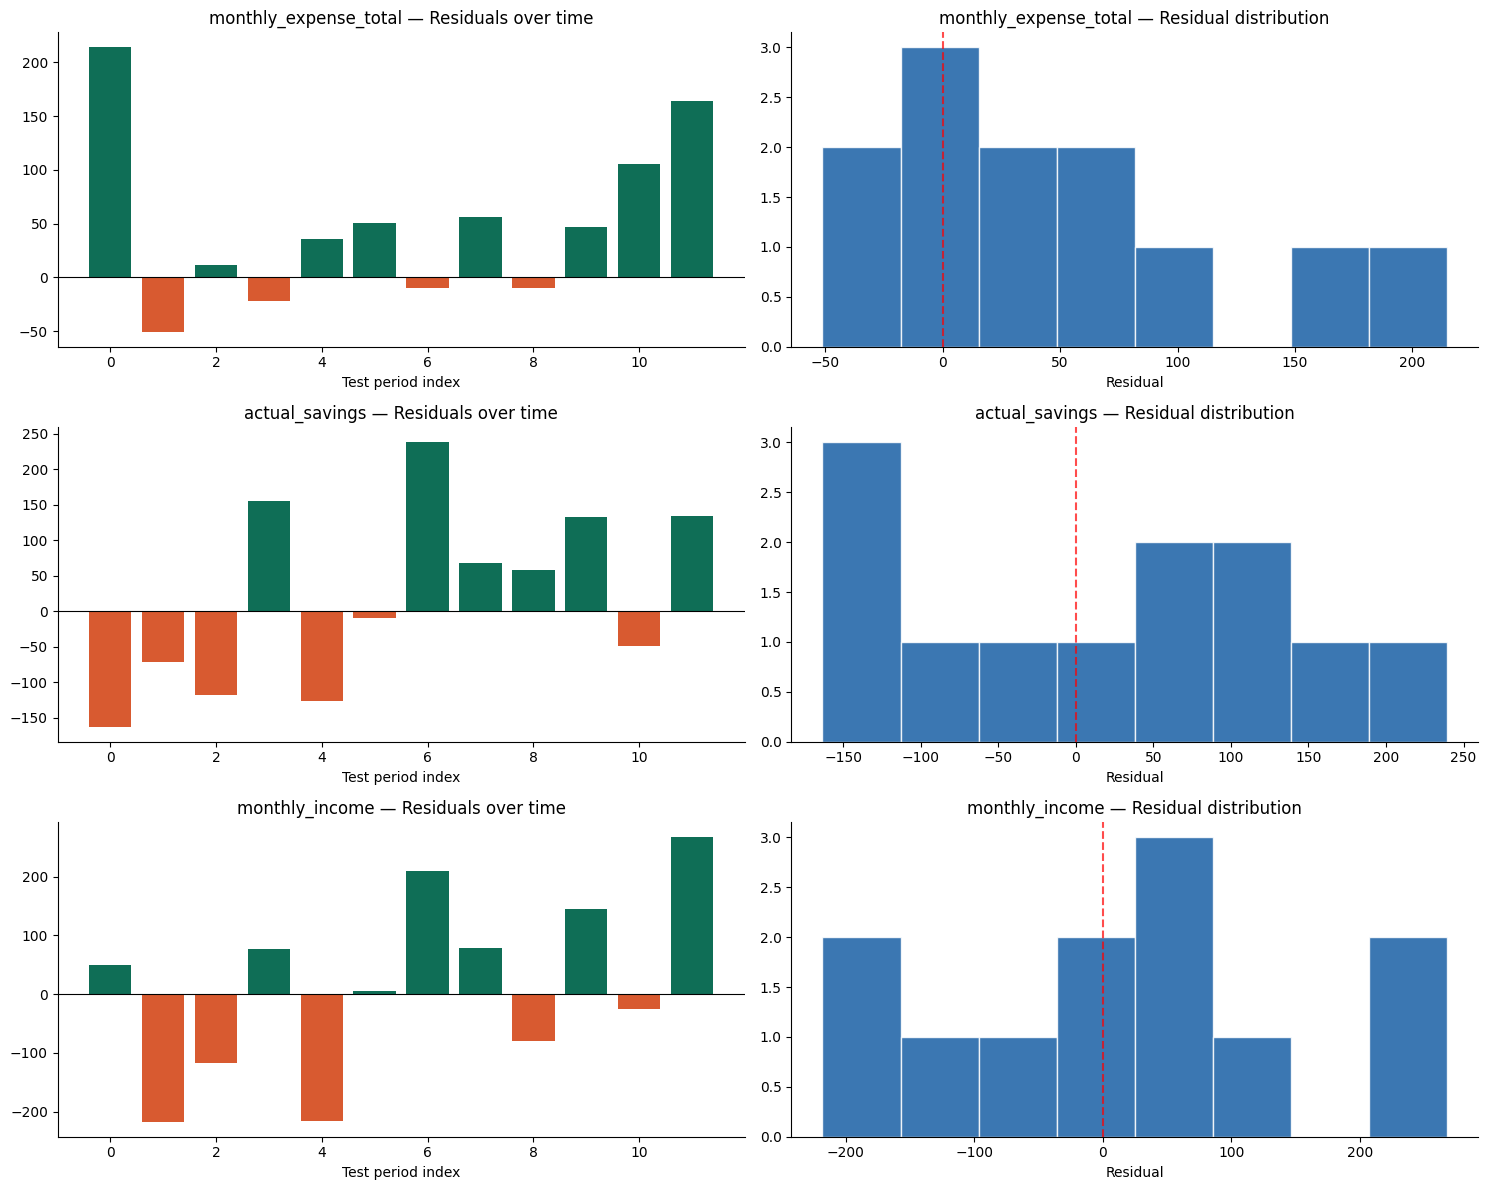

In [37]:
# Residual analysis
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for row, target in enumerate(TARGETS):
    vals  = monthly[target].values.astype(float)
    train = vals[:n_train]
    test  = vals[n_train:]
    alpha = best_alphas[target]
    preds = predict_test(train, n_test, alpha)
    resid = test - preds

    # Residual over time
    axes[row, 0].bar(range(n_test), resid,
                     color=np.where(resid >= 0, '#0F6E56', '#D85A30'),
                     edgecolor='none')
    axes[row, 0].axhline(0, color='black', linewidth=0.8)
    axes[row, 0].set_title(f'{target} — Residuals over time')
    axes[row, 0].set_xlabel('Test period index')

    # Residual histogram
    axes[row, 1].hist(resid, bins=8, color='#185FA5', edgecolor='white', alpha=0.85)
    axes[row, 1].axvline(0, color='red', linestyle='--', alpha=0.7)
    axes[row, 1].set_title(f'{target} — Residual distribution')
    axes[row, 1].set_xlabel('Residual')

plt.tight_layout()
plt.show()


## 7. Forecast Future Periods

In [38]:
def forecast(all_data, alpha, n_steps):
    """Re-train on all data with best alpha, then project n_steps forward."""
    smoothed = exp_smooth(all_data, alpha)
    s = smoothed[-1]
    preds = []
    for _ in range(n_steps):
        s = alpha * s + (1 - alpha) * s
        preds.append(s)
    return np.array(preds)

last_date     = monthly.index[-1]
future_dates  = pd.date_range(start=last_date + pd.offsets.Day(30),
                               periods=FORECAST_N, freq='30D')

print(f"{FORECAST_N}-Period Forecast:\n")
forecasts = {}
for target in TARGETS:
    vals = monthly[target].values.astype(float)
    alpha = best_alphas[target]
    fut = forecast(vals, alpha, FORECAST_N)
    forecasts[target] = fut
    print(f"  {target}  (α={alpha})")
    for d, v in zip(future_dates, fut):
        print(f"    {d.strftime('%b %Y')} → {v:,.2f}")
    print()


3-Period Forecast:

  monthly_expense_total  (α=0.1)
    Dec 2023 → 3,040.02
    Jan 2024 → 3,040.02
    Feb 2024 → 3,040.02

  actual_savings  (α=0.1)
    Dec 2023 → 1,193.94
    Jan 2024 → 1,193.94
    Feb 2024 → 1,193.94

  monthly_income  (α=0.9)
    Dec 2023 → 4,309.97
    Jan 2024 → 4,309.97
    Feb 2024 → 4,309.97



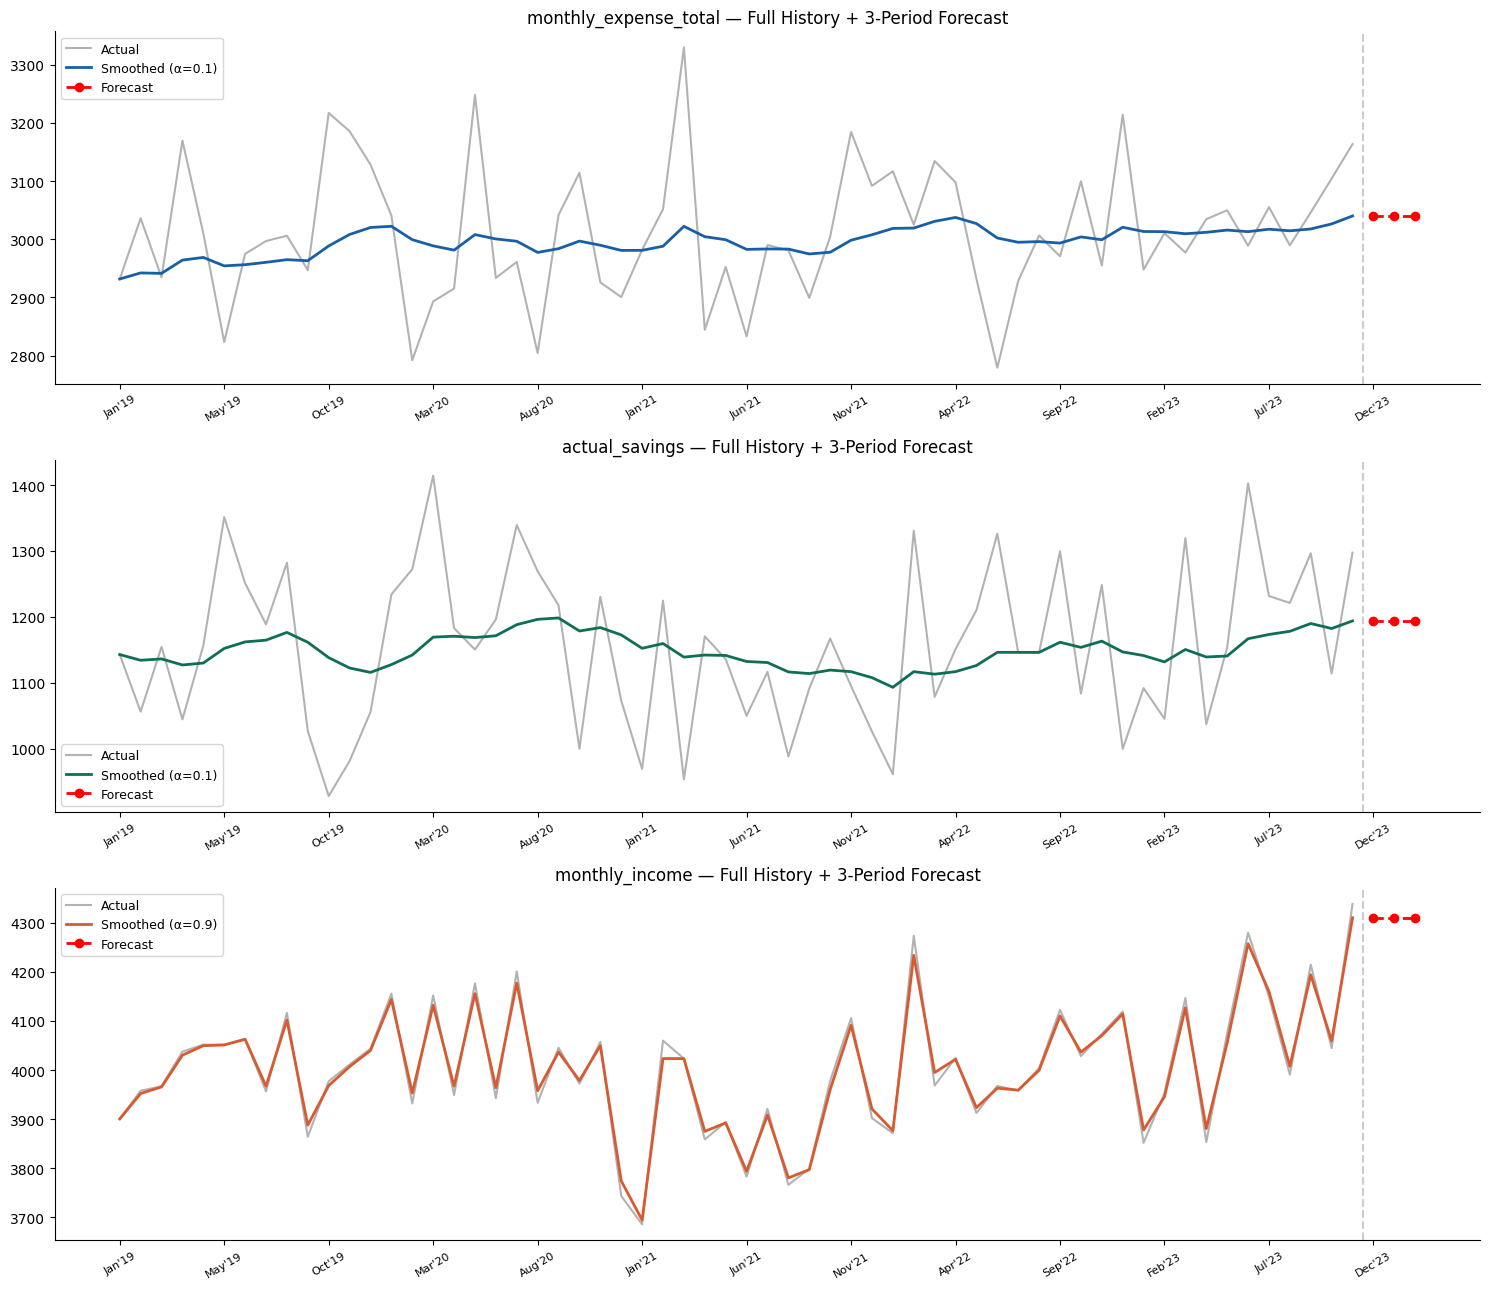

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(15, 13))
colors = ['#185FA5', '#0F6E56', '#D85A30']

for ax, target, color in zip(axes, TARGETS, colors):
    vals  = monthly[target].values.astype(float)
    alpha = best_alphas[target]
    smoothed = exp_smooth(vals, alpha)
    fut = forecasts[target]

    all_x       = list(range(n))
    future_x    = list(range(n, n + FORECAST_N))

    ax.plot(all_x, vals,     color='gray',  linewidth=1.5, alpha=0.6, label='Actual')
    ax.plot(all_x, smoothed, color=color,   linewidth=2,   label=f'Smoothed (α={alpha})')
    ax.plot(future_x, fut,   'o--',         color='red',   linewidth=2, markersize=6, label='Forecast')
    ax.axvline(n - 0.5, color='gray', linestyle='--', alpha=0.4)

    xticks = list(range(0, n + FORECAST_N, 5))
    xlabels = [(monthly.index[i] if i < n else future_dates[i - n]).strftime("%b'%y")
               for i in xticks]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation=30, fontsize=8)
    ax.set_title(f'{target} — Full History + {FORECAST_N}-Period Forecast')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 8. Bonus: Per-User Exponential Smoothing

The above used population averages. You can also apply smoothing to individual users.


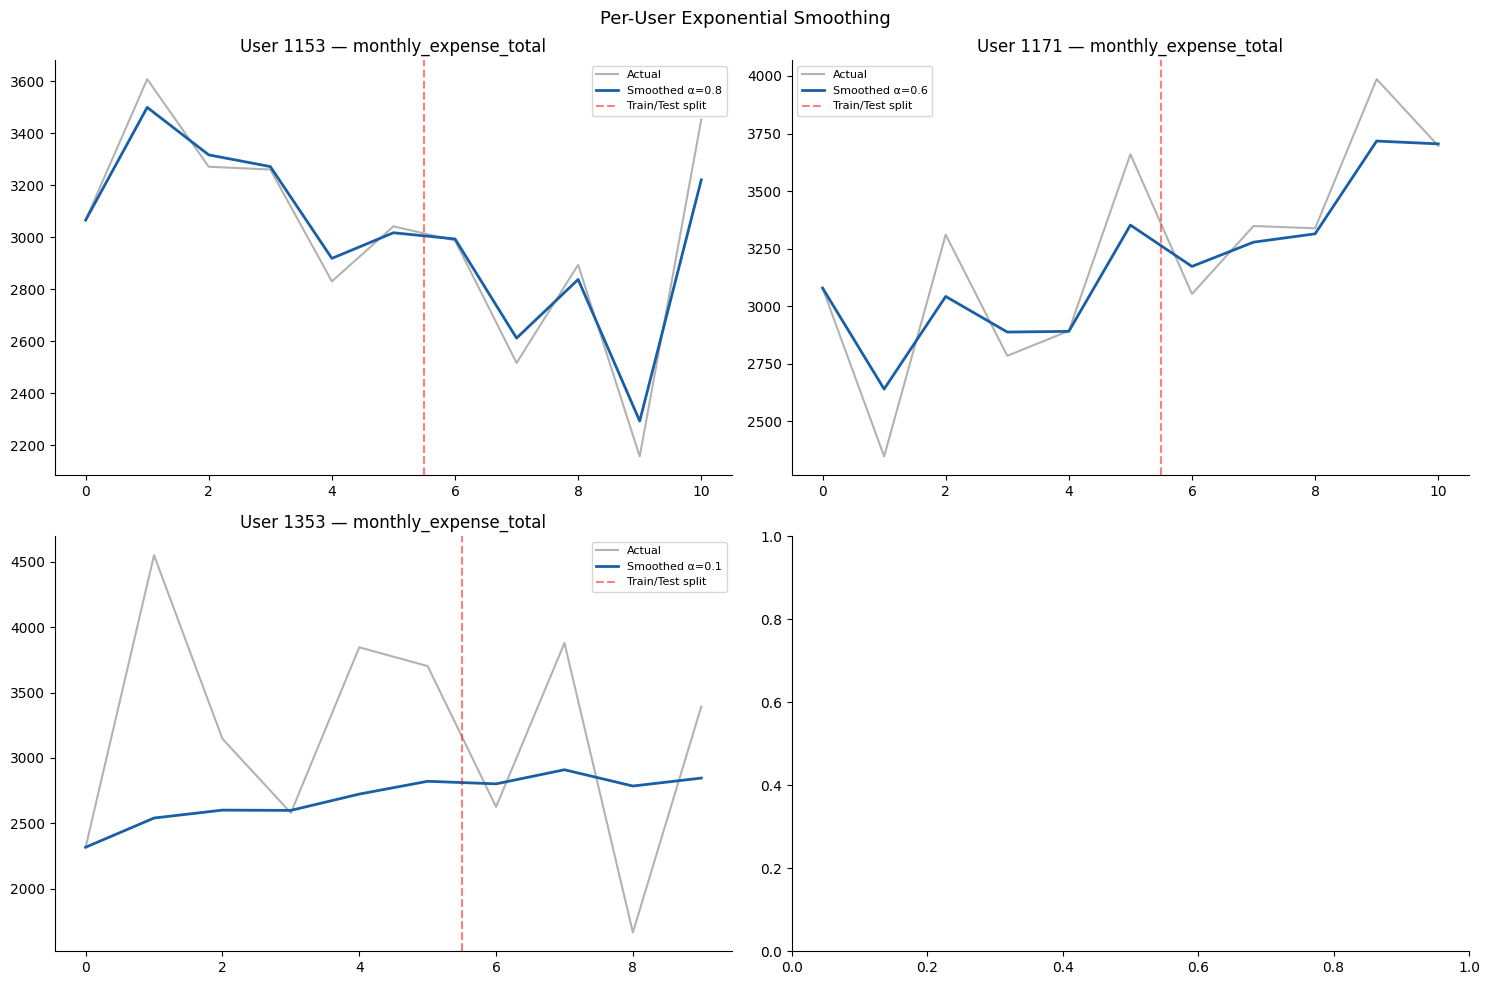

In [40]:
# Pick a few users with enough data points
user_counts = df.groupby('user_id')['date'].count()
active_users = user_counts[user_counts >= 10].index[:4]  # 4 users with 10+ periods

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, uid in zip(axes.flat, active_users):
    user_df = df[df['user_id'] == uid].sort_values('date')
    vals    = user_df['monthly_expense_total'].values.astype(float)

    if len(vals) < 3:
        continue

    n_u = len(vals)
    n_t = int(n_u * 0.6)

    train_u = vals[:n_t]
    test_u  = vals[n_t:]

    # Quick grid search for this user
    best_a, best_m = 0.1, np.inf
    for a in ALPHA_RANGE:
        if len(test_u) == 0:
            break
        p = np.full(len(test_u), exp_smooth(train_u, a)[-1])
        m = mae(test_u, p)
        if m < best_m:
            best_m, best_a = m, a

    smoothed_u = exp_smooth(vals, best_a)
    ax.plot(vals,       color='gray',    linewidth=1.5, alpha=0.6, label='Actual')
    ax.plot(smoothed_u, color='#185FA5', linewidth=2,   label=f'Smoothed α={best_a}')
    ax.axvline(n_t - 0.5, color='red', linestyle='--', alpha=0.5, label='Train/Test split')
    ax.set_title(f'User {uid} — monthly_expense_total')
    ax.legend(fontsize=8)

plt.suptitle('Per-User Exponential Smoothing', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Summary

| Target | Best α | Interpretation |
|--------|--------|----------------|
| `monthly_expense_total` | 0.2 | Stable series — slow smooth works best |
| `actual_savings` | 0.1 | Very stable — nearly all history equally weighted |
| `monthly_income` | 0.1 | Stable income trend — low α generalises best |


